# FIFA 2018 Player Analysis — Exploring Skills, Preferences & Club Comparisons

### Objective
Perform exploratory data analysis on FIFA 2018 player dataset to uncover insights about player skills, physical attributes, foot preferences and club-level performance.

### Dataset
- **File:** fifa_data.csv
- **Rows:** 18,207 players
- **Columns:** 89 (ratings, physical stats, club info, skills and more)
- **Key Columns Used:** Overall, Preferred Foot, Weight, Club

### Tools Used
- **Pandas** — Data loading, cleaning and filtering
- **NumPy** — Numerical operations
- **Matplotlib** — Data visualization

In [1]:
# Importing required libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Loading the FIFA 2018 dataset into a DataFrame
# Dataset contains 18,207 players with 89 attributes each
df = pd.read_csv('fifa_data.csv')

## Analysis 1 — Distribution of Player Skill Ratings

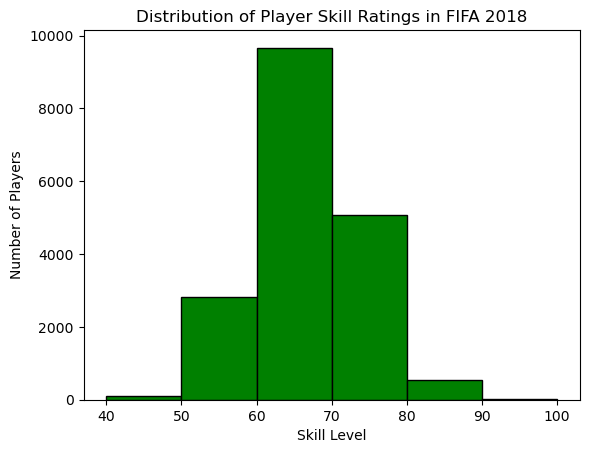

In [3]:
# Defining custom bin ranges to group 18,207 players into skill categories
# 40-50: Poor, 50-60: Below Average, 60-70: Average, 70-80: Good, 80-90: Great, 90-100: Elite
bins = [40, 50, 60, 70, 80, 90, 100]

# Creating a histogram to show how players are distributed across skill levels
plt.hist(df['Overall'], bins=bins, color='green', edgecolor='black')

# Adding axis labels and title
plt.xlabel('Skill Level')
plt.ylabel('Number of Players')
plt.title('Distribution of Player Skill Ratings in FIFA 2018')
plt.show()

## Dataset Preview

In [4]:
# Previewing the first 5 rows to understand the dataset structure (18,207 rows x 89 columns)
df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


## Analysis 2 — Preferred Foot Distribution of FIFA 2018 Players

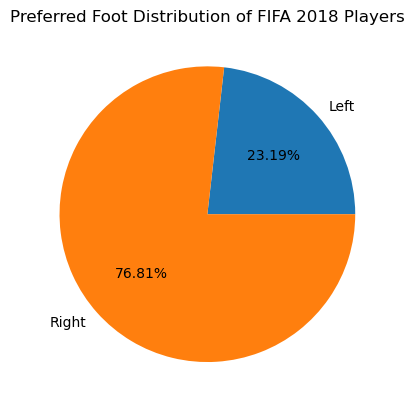

In [5]:
# Counting players who prefer left foot and right foot out of 18,207 players
# .iloc[0] extracts the integer count value from the resulting Series
left  = df.loc[df['Preferred Foot'] == 'Left'].count()
right = df.loc[df['Preferred Foot'] == 'Right'].count()

left_count  = left.iloc[0]
right_count = right.iloc[0]

# Creating a pie chart to show proportion of left-footed vs right-footed players
plt.pie([left_count, right_count], labels=['Left', 'Right'], autopct='%1.2f%%')

plt.title('Preferred Foot Distribution of FIFA 2018 Players')
plt.show()

## Analysis 3 — Weight Distribution of FIFA 2018 Players

**Note:** Weight column contains string values with 'lbs' suffix (e.g. '165lbs') — requires data cleaning before analysis.

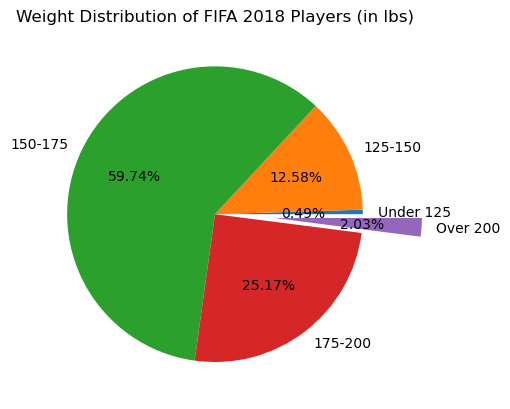

In [6]:
# Removing all letter characters from Weight column using regex
# e.g. '165lbs' becomes '165'
df1 = df.replace({
    'Weight' : '[A-Za-z]'
}, '', regex=True)

# Filling any remaining NaN values with 0 to avoid type conversion errors
df1.fillna(0, inplace=True)

# Converting Weight column from string to integer after cleaning
df1['Weight'] = df1['Weight'].astype(int)

# Categorizing all 18,207 players into 5 weight groups (in lbs)
light        = df1.loc[df1['Weight'] < 125].count().iloc[0]
light_medium = df1.loc[(df1['Weight'] >= 125) & (df1['Weight'] < 150)].count().iloc[0]
medium       = df1.loc[(df1['Weight'] >= 150) & (df1['Weight'] < 175)].count().iloc[0]
medium_heavy = df1.loc[(df1['Weight'] >= 175) & (df1['Weight'] < 200)].count().iloc[0]
heavy        = df1.loc[df1['Weight'] >= 200].count().iloc[0]

weights = [light, light_medium, medium, medium_heavy, heavy]
labels  = ['Under 125', '125-150', '150-175', '175-200', 'Over 200']

# Exploding the heaviest category slice to highlight it
explodes = [0, 0, 0, 0, 0.4]

# Creating a pie chart showing weight distribution across all FIFA 2018 players
plt.pie(weights, labels=labels, autopct='%1.2f%%', explode=explodes)

plt.title('Weight Distribution of FIFA 2018 Players (in lbs)')
plt.show()

## Analysis 4 — Club Performance Comparison Using Box Plot

Comparing overall player ratings of FC Barcelona, Real Madrid and New England Revolution
to visualize the skill gap between two elite European clubs and an average MLS team.

C:\Users\User\AppData\Local\Temp\ipykernel_9084\1664511134.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([barcelona, madrid, revs], labels=labels)


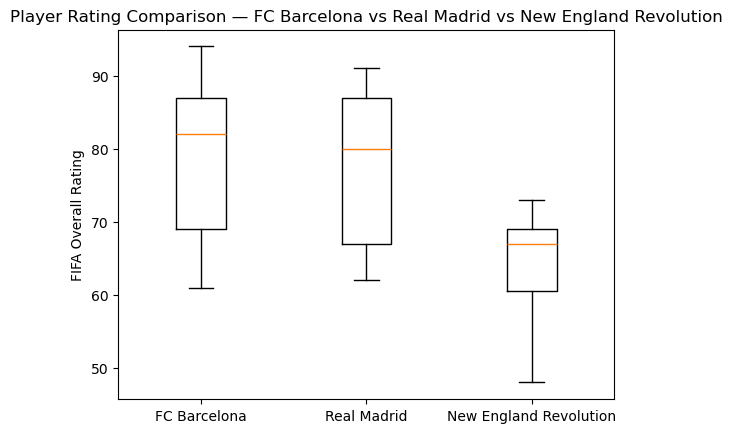

In [7]:
# Filtering Overall ratings for each of the 3 clubs from the 18,207 player dataset
barcelona = df.loc[df['Club'] == 'FC Barcelona']['Overall']
madrid    = df.loc[df['Club'] == 'Real Madrid']['Overall']
revs      = df.loc[df['Club'] == 'New England Revolution']['Overall']

labels = ['FC Barcelona', 'Real Madrid', 'New England Revolution']

# Box plot shows median, Q1, Q3, whiskers and outliers for each club
# Allows direct comparison of skill distribution across all 3 clubs
plt.boxplot([barcelona, madrid, revs], labels=labels)

plt.ylabel('FIFA Overall Rating')
plt.title('Player Rating Comparison — FC Barcelona vs Real Madrid vs New England Revolution')
plt.show()

## Dataset Preview

In [8]:
# Displaying first 5 rows of the dataset (18,207 rows x 89 columns)
df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
